# [Polynomial Regression](https://www.geeksforgeeks.org/machine-learning/python-implementation-of-polynomial-regression/)

Polynomial Regression is a form of linear regression where the relationship between the independent variable (x) and the dependent variable (y) is modelled as an n<sup>th</sup> degree polynomial. It is useful when the data exhibits a non-linear relationship allowing the model to fit a curve to the data.

In [6]:
import numpy as np
import matplotlib.pyplot as plt


class PolynomialRegression:
    def __init__(self, degree=2):
        self.degree = degree
        self.coefficients = None

    def fit(self, X, y):
        """
        Fit polynomial regression using least squares.

        y = b0 + b1*x + b2*x² + ... + bn*xⁿ
        """
        X = np.array(X)
        y = np.array(y)

        X_poly = np.vander(
            X,
            N=self.degree + 1,
            increasing=True,
        )

        self.coefficients = np.linalg.inv(
            X_poly.T @ X_poly
        ) @ X_poly.T @ y
      
    def predict(self, X):
        X = np.array(X)

        X_poly = np.vander(
            X,
            N=self.degree + 1,
            increasing=True,
        )

        return X_poly @ self.coefficients

    def calculate_metrics(self, X, y):
        X = np.array(X)
        y = np.array(y)

        predictions = self.predict(X)

        y_mean = np.mean(y)

        ss_total = np.sum((y - y_mean) ** 2)
        ss_residual = np.sum(
            (y - predictions) ** 2
        )

        r_squared = (
            0.0
            if ss_total == 0
            else (ss_total - ss_residual)
            / ss_total
        )

        return (
            ss_total,
            ss_residual,
            r_squared,
        )

    def calculate_p_value(
        self,
        X,
        y,
        n_simulations=10000,
        random_state=42,
    ):
        """
        Permutation test for statistical significance.
        """
        np.random.seed(random_state)

        X = np.array(X)
        y = np.array(y)

        _, _, observed_r2 = (
            self.calculate_metrics(X, y)
        )

        simulated_r2_values = []

        for _ in range(n_simulations):
            y_shuffled = np.random.permutation(y)

            temp_model = (
                PolynomialRegression(
                    degree=self.degree
                )
            )

            temp_model.fit(X, y_shuffled)

            _, _, sim_r2 = (
                temp_model.calculate_metrics(
                    X,
                    y_shuffled,
                )
            )

            simulated_r2_values.append(
                sim_r2
            )

        simulated_r2_values = np.array(
            simulated_r2_values
        )

        extreme_count = np.sum(
            simulated_r2_values >= observed_r2
        )

        p_value = (
            extreme_count / n_simulations
        )

        return p_value

    def equation(self):
        """
        Return human-readable polynomial equation.
        """
        terms = []

        for i, coef in enumerate(
            self.coefficients
        ):
            if i == 0:
                terms.append(
                    f"{coef:.3f}"
                )
            elif i == 1:
                terms.append(
                    f"{coef:+.3f}x"
                )
            else:
                terms.append(
                    f"{coef:+.3f}x^{i}"
                )

        return " ".join(terms)

    def plot(
        self,
        X,
        y,
        title="StatQuest Polynomial Regression",
    ):
        X = np.array(X)
        y = np.array(y)

        x_curve = np.linspace(
            np.min(X),
            np.max(X),
            500,
        )

        y_curve = self.predict(
            x_curve
        )

        _, _, r_squared = (
            self.calculate_metrics(X, y)
        )

        plt.figure(figsize=(8, 5))

        plt.scatter(
            X,
            y,
            s=100,
            label="Observed Data",
        )

        plt.plot(
            x_curve,
            y_curve,
            linewidth=2,
            label=(
                f"Degree {self.degree}"
                " Polynomial"
            ),
        )

        plt.xlabel("X")
        plt.ylabel("y")

        plt.title(
            f"{title}\n"
            f"{self.equation()}\n"
            f"R² = {r_squared:.3f}"
        )

        plt.legend()
        plt.grid(True)
        plt.show()

Equation:
1.000 +1.000x +1.000x^2 -0.000x^3
R² = 1.0000
P-value = 0.001000


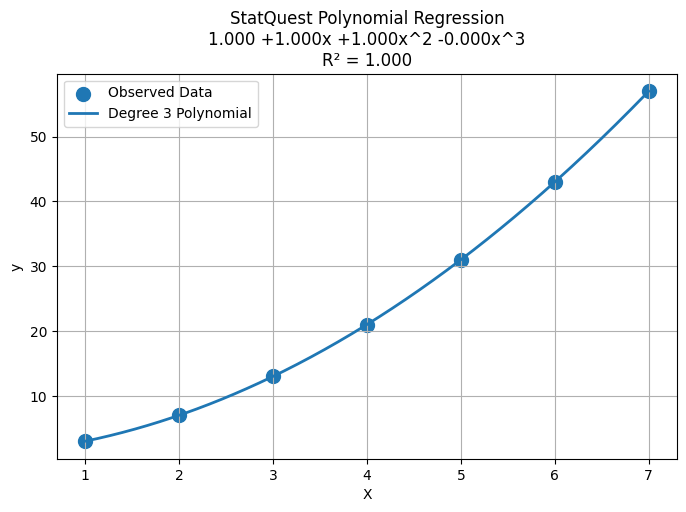

In [9]:
if __name__ == "__main__":
    X = np.array([
        1, 2, 3, 4, 5, 6, 7
    ])
    
    y = np.array([
        3, 7, 13, 21, 31, 43, 57
    ])
    
    model = PolynomialRegression(
        degree=3
    )
    
    model.fit(X, y)
    
    predictions = model.predict(X)
    
    print("Equation:")
    print(model.equation())
    
    ss_total, ss_residual, r2 = (
        model.calculate_metrics(X, y)
    )
    
    print(f"R² = {r2:.4f}")
    
    p_value = model.calculate_p_value(
        X,
        y,
        n_simulations=5000,
    )
    
    print(f"P-value = {p_value:.6f}")
    
    model.plot(X, y)